In [15]:
from datasets import load_dataset
ds = load_dataset("weathon/grpo_dataset")

In [ ]:
import os
import json
import re
rollouts = os.listdir("rollouts")
okay = 0
total = 0
x = []
y = []
for filename in rollouts:
    idx = int(filename.split(".")[0])
    with open(f"rollouts/{filename}", "r") as f:
        data = json.load(f)
        min_diff = 20
        best = 0
        for r in data:
            score = re.search('<score>(.*?)</score>', r)
            if score is not None:
                try:    
                    score = float(score.group(1))
                    diff = abs(score - ds['train'][idx]['solution'])
                    if diff < min_diff:
                        min_diff = diff
                        best = score
                except Exception as e:
                    pass
        if min_diff < 1:
            okay += 1
        x.append(best)
        y.append(ds['train'][idx]['solution'])
            
        total += 1
print(f"Accuracy: {okay/total if total > 0 else 0}")

Accuracy: 0.74943904263276


Pearson correlation: 0.7137835842103311


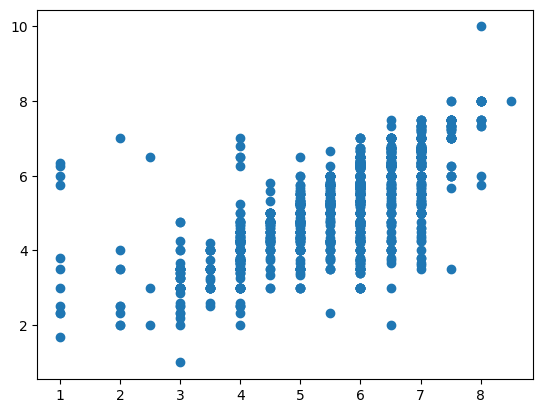

In [ ]:
import pylab
from scipy.stats import pearsonr
corr, _ = pearsonr(x, y)
print(f"Pearson correlation: {corr}")
pylab.scatter(x, y)

In [12]:
def format(ans):
    return [
      {
          "role": "assistant",
          "content": ans
      }
  ]

import os
import json
import re
import numpy as np
rollouts = os.listdir("rollouts")
dpo_ds = []
for filename in rollouts:
    idx = int(filename.split(".")[0])
    gt = ds['train'][idx]['solution']
    with open(f"rollouts/{filename}", "r") as f:
        data = json.load(f)
    min_diff = 20
    best = 0
    scores = []
    for r in data:
        score = re.search('<score>(.*?)</score>', r)
        if score is not None:
            try:    
                score = float(score.group(1))
                scores.append(score)
            except Exception as e:
                print(f"Error parsing score in idx {idx}: {e}")
                scores.append(float('inf'))
    
    
    scores = np.array(scores)
    if np.min(np.abs(scores - gt)) > 2:
        print(f"skipping idx {idx} since all scores are far from gt {gt}")
        continue

    # put the golden sample at the begining so we can slice it
    chosen = np.concatenate([[np.argmin(np.abs(scores - gt))], np.where(np.abs(scores - gt) < 1)[0]])
    chosen = np.unique(chosen)

    this_slide = []
    for c in chosen:
        for i, s in enumerate(scores):
            if abs(s - gt) > abs(scores[c] - gt) and abs(s - gt) > 1:
                this_slide.append({
                    "paper_id": ds['train'][idx]['paper_id'],
                    "prompt": ds['train'][idx]['prompt'],
                    "chosen": format(data[c]),
                    "rejected": format(data[i]),
                    "chosen_diff": abs(scores[c] - gt),
                    "rejected_diff": abs(s - gt), 
                    "gt": gt
                })
            if len(this_slide) > 10:
                break
        if len(this_slide) > 10:
            break
    dpo_ds.extend(this_slide)         

Error parsing score in idx 214: could not convert string to float: '7.5  0'
skipping idx 119 since all scores are far from gt 4.75
skipping idx 16 since all scores are far from gt 3.5
skipping idx 208 since all scores are far from gt 6.5
skipping idx 173 since all scores are far from gt 5.0
skipping idx 149 since all scores are far from gt 4.75
skipping idx 104 since all scores are far from gt 3.0
skipping idx 166 since all scores are far from gt 3.0
skipping idx 205 since all scores are far from gt 3.0
skipping idx 140 since all scores are far from gt 7.0
skipping idx 207 since all scores are far from gt 4.75
skipping idx 215 since all scores are far from gt 4.5
skipping idx 153 since all scores are far from gt 3.4
skipping idx 195 since all scores are far from gt 5.75
skipping idx 89 since all scores are far from gt 4.25
skipping idx 218 since all scores are far from gt 3.4
skipping idx 32 since all scores are far from gt 3.8


In [13]:
len(dpo_ds)

1712

In [14]:
import random
all_ids = list(ds['train']['paper_id'])
selected_ids = random.sample(all_ids, 10) 

In [7]:
dpo_ds_train = [d for d in dpo_ds if d['paper_id'] not in selected_ids]
dpo_ds_test = [d for d in dpo_ds if d['paper_id'] in selected_ids]

In [8]:
from datasets import Dataset, DatasetDict
dpo_ds_train = Dataset.from_list(dpo_ds_train)
dpo_ds_test = Dataset.from_list(dpo_ds_test)
dpo_ds = DatasetDict(
    {
        "train": dpo_ds_train,
        "test": dpo_ds_test
    }
)

In [9]:
dpo_ds

DatasetDict({
    train: Dataset({
        features: ['paper_id', 'prompt', 'chosen', 'rejected', 'chosen_diff', 'rejected_diff', 'gt'],
        num_rows: 1371
    })
    test: Dataset({
        features: [],
        num_rows: 0
    })
})

In [ ]:
5/0

In [10]:
dpo_ds.push_to_hub("weathon/dpo_ds_hf")

ValueError: All datasets in `DatasetDict` should have the same features but features for 'train' and 'test' don't match: {'paper_id': Value('string'), 'prompt': List({'content': Value('string'), 'role': Value('string')}), 'chosen': List({'content': Value('string'), 'role': Value('string')}), 'rejected': List({'content': Value('string'), 'role': Value('string')}), 'chosen_diff': Value('float64'), 'rejected_diff': Value('float64'), 'gt': Value('float64')} != {}